Saving AV.png to AV.png
Applying High-Clarity Stylization...


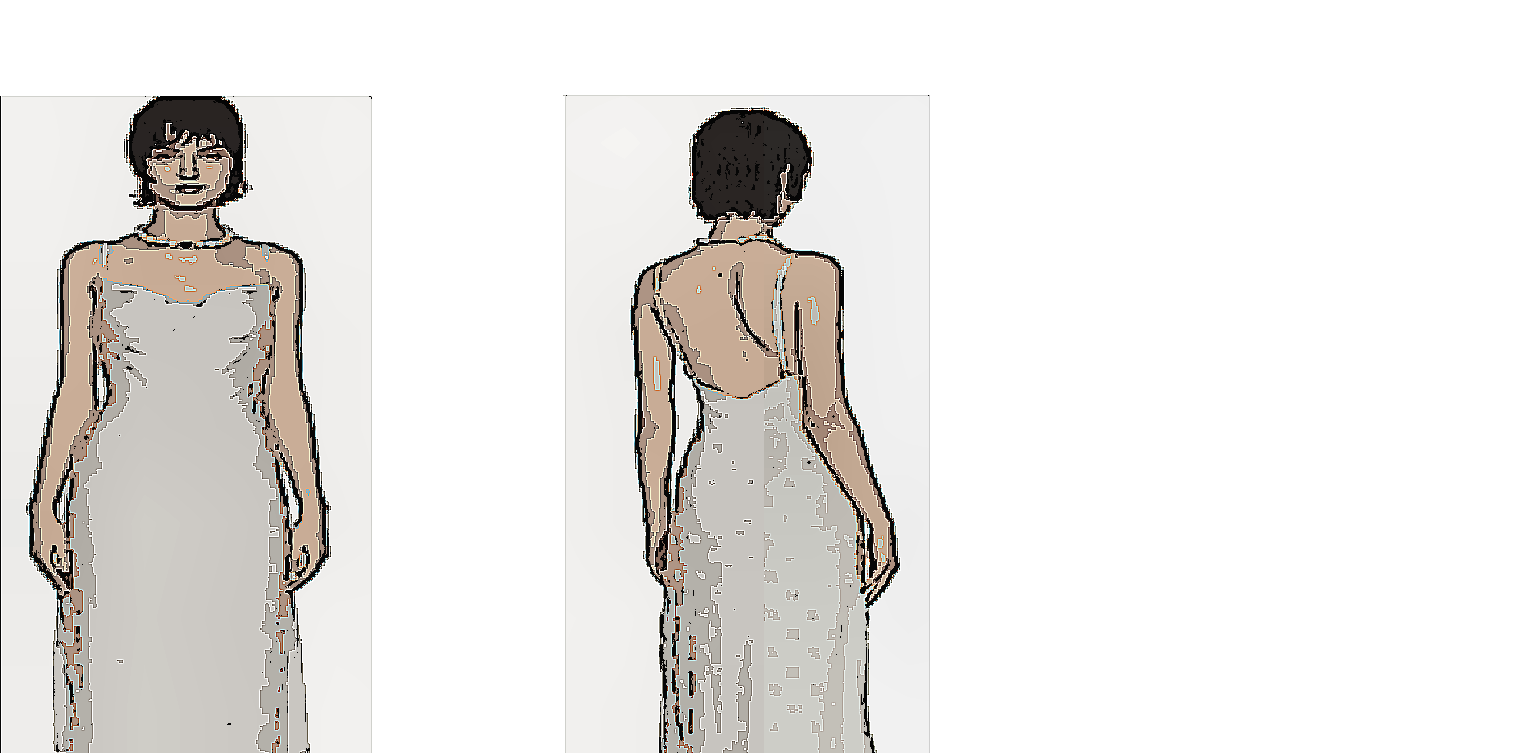

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# @title High-Clarity Stylized Avatar
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# 1. UPLOAD
uploaded = files.upload()
raw_name = list(uploaded.keys())[0]
img = cv2.imread(raw_name)

def stylize_v2(image):
    # STEP A: Create a High-Contrast Edge Map (for the 'Anime' outline)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.medianBlur(gray, 3)
    # Thinner lines to keep the face clear
    edges = cv2.adaptiveThreshold(gray_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 11, 5)

    # STEP B: Color Preservation Layer
    # We use a quantized color palette to keep the black 'Black'
    data = np.float32(image).reshape((-1, 3))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.001)
    # K=8 keeps the original colors distinct without washing them out
    ret, label, center = cv2.kmeans(data, 8, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    center = np.uint8(center)
    quantized = center[label.flatten()]
    quantized = quantized.reshape((image.shape))

    # STEP C: Face Enhancement
    # We apply a slight sharpening to the original image to mix back in
    sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharp_face = cv2.filter2D(quantized, -1, sharpen_kernel)

    # STEP D: Final Merge
    # We blend the sharp colors with the edge map
    cartoon = cv2.bitwise_and(sharp_face, sharp_face, mask=edges)

    # Boost contrast to fix the "changing dress color" issue
    lab = cv2.cvtColor(cartoon, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    return final

# 2. PROCESS
h, w, _ = img.shape
front_view = img[:, 0:w//2]
back_view = img[:, w//2:]

print("Applying High-Clarity Stylization...")
res_front = stylize_v2(front_view)
res_back = stylize_v2(back_view)

# 3. DISPLAY
combined = cv2.hconcat([res_front, res_back])
cv2_imshow(combined)

cv2.imwrite('Clear_Anime_Front.png', res_front)
cv2.imwrite('Clear_Anime_Back.png', res_back)
files.download('Clear_Anime_Front.png')